In [57]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
import seaborn as sns

This Notebook is for descriptive temporal analysis only. As we do not need Census Tract values for this, we can work with the big dataset of the taxidata.

In [18]:
taxi_data = pd.read_parquet(
    "../data/processed/taxi_data_processed_big.parquet"
)
taxi_data.info()

<class 'pandas.DataFrame'>
Index: 14494804 entries, 0 to 16086254
Data columns (total 22 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Trip ID                     str    
 1   Taxi ID                     str    
 2   Trip Start Timestamp        str    
 3   Trip End Timestamp          str    
 4   Trip Seconds                float64
 5   Trip Miles                  float64
 6   Pickup Census Tract         float64
 7   Dropoff Census Tract        float64
 8   Pickup Community Area       float64
 9   Dropoff Community Area      float64
 10  Trip Total                  float64
 11  Company                     str    
 12  Pickup Centroid Latitude    float64
 13  Pickup Centroid Longitude   float64
 14  Dropoff Centroid Latitude   float64
 15  Dropoff Centroid Longitude  float64
 16  h3_index_pickup_7           str    
 17  h3_index_dropoff_7          str    
 18  h3_index_pickup_8           str    
 19  h3_index_dropoff_8          str    

## 1. Preparation


In [19]:
#drop all spatial columns as they are not needed for temporal analysis
taxi_data = taxi_data.drop(columns=["Pickup Census Tract", "Dropoff Census Tract", 
                                    "Pickup Community Area", "Dropoff Community Area", 
                                    "h3_index_pickup_7", "h3_index_dropoff_7",
                                    "h3_index_pickup_8", "h3_index_dropoff_8",
                                    "h3_index_pickup_9", "h3_index_dropoff_9",
                                    "Pickup Centroid Latitude", "Dropoff Centroid Latitude",
                                    "Pickup Centroid Longitude", "Dropoff Centroid Longitude"])

In [20]:
#convert to datetime
taxi_data["Trip Start Timestamp"] = pd.to_datetime(
    taxi_data["Trip Start Timestamp"]
)

taxi_data["Trip End Timestamp"] = pd.to_datetime(
    taxi_data["Trip End Timestamp"]
)

C:\Users\Larissa\AppData\Local\Temp\ipykernel_4528\3637372849.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  taxi_data["Trip Start Timestamp"] = pd.to_datetime(
C:\Users\Larissa\AppData\Local\Temp\ipykernel_4528\3637372849.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  taxi_data["Trip End Timestamp"] = pd.to_datetime(


We create further features to analyse the dataset.

In [41]:
#create temporal features
taxi_data["date"] = taxi_data["Trip Start Timestamp"].dt.date

taxi_data["year"] = taxi_data["Trip Start Timestamp"].dt.year

taxi_data["month"] = taxi_data["Trip Start Timestamp"].dt.month

taxi_data["week"] = taxi_data["Trip Start Timestamp"].dt.isocalendar().week
taxi_data["weekday_name"] = taxi_data["Trip Start Timestamp"].dt.day_name()
taxi_data["is_weekend"] = taxi_data["weekday_name"].isin(["Saturday", "Sunday"])

taxi_data["hour"] = taxi_data["Trip Start Timestamp"].dt.hour

#trip duration in minutes
taxi_data["Trip Minutes"] = taxi_data["Trip Seconds"] / 60

#average speed (mph)
taxi_data["average_speed"] = np.where(
    taxi_data["Trip Seconds"] > 0,
    taxi_data["Trip Miles"] / (taxi_data["Trip Seconds"] / 3600),
    np.nan,
)

taxi_data

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Trip Total,Company,date,year,month,week,weekday_name,weekday,hour,is_weekend,Trip Minutes,Average Speed (mph),average_speed
0,7bb35d509b4a23a4d5deae7018a80bdd5f87c952,8b07f9156e568a37d362463c84dbd1118b4eeb753bae50...,2026-06-01,2026-06-01 00:00:00,300.000,1.20,1125.0,Choice Taxi Association Inc,2026-06-01,2026,6,23,Monday,Monday,0,False,5.000000,14.400000,14.400000
1,6630e8872591a9a915ad804f5ce3b34a4654663a,6cf97b9e8e3e1c183c090cdd868df381de772a52987239...,2026-06-01,2026-06-01 00:00:00,445.000,1.50,892.0,Flash Cab,2026-06-01,2026,6,23,Monday,Monday,0,False,7.416667,12.134831,12.134831
2,51e2af26f6d9c93afc6e4f1b26a9bf6a3fa7700d,3665a72ee495b03f4dae72307dc6e5e58e21518f77d8e6...,2026-06-01,2026-06-01 00:00:00,0.000,0.00,1038.0,Transit Administrative Center Inc,2026-06-01,2026,6,23,Monday,Monday,0,False,0.000000,NaN,NaN
3,fe861de7a4b804177aa770afd5134dd22758a593,780424fddffb94d4d8541780c7ad1a953ef87d12a20def...,2026-06-01,2026-06-01 00:00:00,4.000,0.00,4860.0,Globe Taxi,2026-06-01,2026,6,23,Monday,Monday,0,False,0.066667,0.000000,0.000000
4,e2627bcf1c079e0b086cb8dbfc34d6ea955a899a,d5c821e78bf25431862f40219794e4d023679198afeb74...,2026-06-01,2026-06-01 00:00:00,380.000,1.30,833.0,Taxicab Insurance Agency Llc,2026-06-01,2026,6,23,Monday,Monday,0,False,6.333333,12.315789,12.315789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16086248,979a99625daee328ef36e2858f655f09e736c0a5,8f35ce7248373090931a3261c8da3d73ebc5b81bd4546d...,2024-01-01,2024-01-01 00:30:00,2.040,21.31,5825.0,Sun Taxi,2024-01-01,2024,1,1,Monday,Monday,0,False,0.034000,37605.882353,37605.882353
16086250,fc08277cee8647cb9a4eb700da02ce287029ca2a,3618045f9110d4d88482266ade23659c1a50d32ac37f20...,2024-01-01,2024-01-01 00:15:00,840.000,7.10,2025.0,Taxi Affiliation Services,2024-01-01,2024,1,1,Monday,Monday,0,False,14.000000,30.428571,30.428571
16086252,bdc420394ce5e864465df0a361dfbe95a4e228c4,389f01c14b097ed951468ff163ccc71ebcb99a27e523e9...,2024-01-01,2024-01-01 00:30:00,1.369,3.07,2600.0,Medallion Leasin,2024-01-01,2024,1,1,Monday,Monday,0,False,0.022817,8073.046019,8073.046019
16086253,70679bacef2403edfa376cd42f2b04037e7534c1,8123ec5a70681a139fcd93fd477eec0ee05dda82987748...,2024-01-01,2024-01-01 00:15:00,584.000,0.43,775.0,Globe Taxi,2024-01-01,2024,1,1,Monday,Monday,0,False,9.733333,2.650685,2.650685


## 2. Overall Demand
### 2.1 Daily Demand

In [49]:
# Number of trips per day
daily_demand = (
    taxi_data
    .groupby("date")
    .size()
    .rename("trip_count")
    .reset_index()
)

daily_demand

,date,trip_count
0,2024-01-01,8428
1,2024-01-02,11228
2,2024-01-03,12036
3,2024-01-04,12429
4,2024-01-05,11525
...,...,...
878,2026-05-28,22731
879,2026-05-29,24144
880,2026-05-30,20599
881,2026-05-31,18001


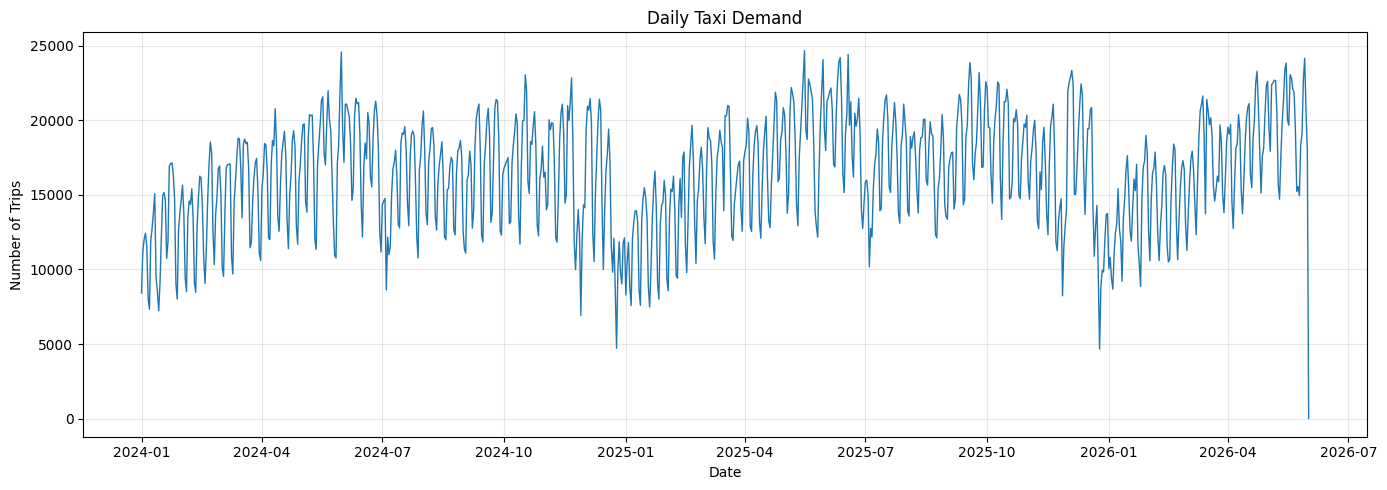

In [45]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_demand["date"],
    daily_demand["trip_count"],
    linewidth=1
)

plt.title("Daily Taxi Demand")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The daily number of taxi trips exhibits a pronounced weekly cycle. Demand regularly increases and decreases at approximately seven-day intervals, indicating systematic differences between weekdays and weekends.

Beyond this weekly pattern, the overall demand shows moderate long-term fluctuations. Demand is generally lower at the beginning of 2024, increases towards mid-2024, decreases again around the turn of the year 2024/2025, and rises afterwards.

Several days exhibit unusually low trip counts. These may correspond to public holidays, extreme weather events, data collection issues, or incomplete observations. The final observation with zero trips is most likely caused by an incomplete recording of the last day and should therefore not be interpreted as an actual demand pattern.

### 2.2 Weekly Demand

In [48]:
weekly_demand = (
    taxi_data
    .groupby(["year", "week"])
    .size()
    .rename("trip_count")
    .reset_index()
)

weekly_demand["year_week"] = (
    weekly_demand["year"].astype(str)
    + "-W"
    + weekly_demand["week"].astype(str).str.zfill(2)
)

weekly_demand

,year,week,trip_count,year_week
0,2024,1,94919,2024-W01
1,2024,2,78809,2024-W02
2,2024,3,88686,2024-W03
3,2024,4,99340,2024-W04
4,2024,5,88428,2024-W05
...,...,...,...,...
122,2026,19,141160,2026-W19
123,2026,20,145739,2026-W20
124,2026,21,139856,2026-W21
125,2026,22,137910,2026-W22


In [ ]:
#TODO: delete data from last day from the dataset, as it shows an uncomplete pattern and could distort the analysis

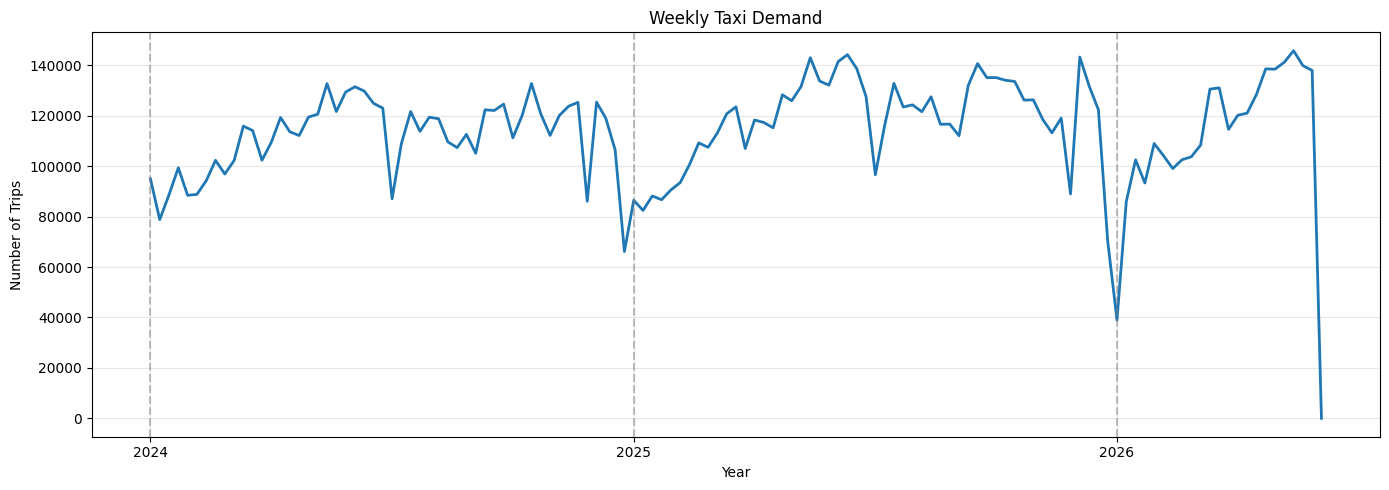

In [50]:
# Position of the first week of each year
year_start_positions = (
    weekly_demand
    .groupby("year")
    .head(1)
    .index
)

year_labels = (
    weekly_demand
    .groupby("year")
    .head(1)["year"]
)

plt.figure(figsize=(14,5))

plt.plot(
    weekly_demand.index,
    weekly_demand["trip_count"],
    linewidth=2
)

# Mark the beginning of each year
for pos in year_start_positions:
    plt.axvline(pos, color="grey", linestyle="--", alpha=0.5)

plt.xticks(
    year_start_positions,
    year_labels
)

plt.title("Weekly Taxi Demand")
plt.xlabel("Year")
plt.ylabel("Number of Trips")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Aggregating demand on a weekly basis removes most of the short-term fluctuations and highlights broader temporal trends. Weekly demand varies between approximately 80,000 and 145,000 trips.

Demand decreases noticeably around the beginning of each year before recovering in the following months. Such recurring reductions are likely related to seasonal effects, for example lower travel activity during holiday periods.

The sharp decline in the final week is caused by incomplete data and should therefore be excluded from further analyses.

## 3 Intraday patterns

### 3.1 Demand by Hour of the Day

In [ ]:
hourly_demand = taxi_data.groupby("hour").size()
weekly_demand = taxi_data.groupby("weekday").size()

#hourly_demand

hour
0      205911
1      120712
2       73636
3       59159
4       75686
5      137627
6      281628
7      547964
8      804336
9      861612
10     824159
11     872040
12     935966
13     952592
14     968267
15    1004515
16    1032097
17    1057423
18     964937
19     797792
20     638049
21     538766
22     431629
23     308301
dtype: int64

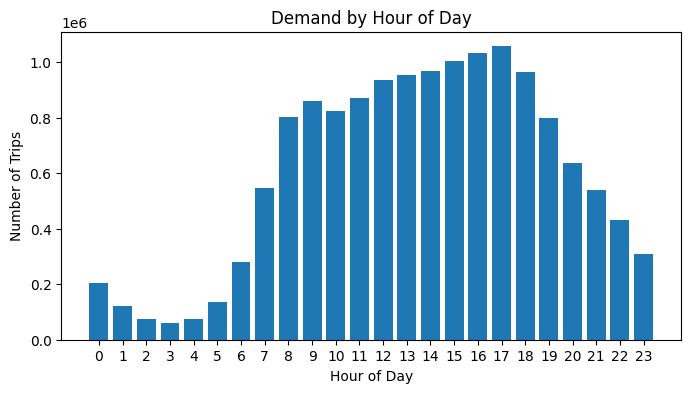

In [54]:
plt.figure(figsize=(8, 4))
plt.bar(hourly_demand.index, hourly_demand.values)

plt.title("Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))

plt.show()

The observed pattern reflects typical daily mobility behaviour. Demand is lowest during the early morning hours when most people are inactive. Beginning with the morning commute, demand increases rapidly and remains high throughout normal business hours. The peak in the late afternoon is likely associated with commuters returning home as well as increased leisure activities after work.

### 3.2 Weekday vs Weekend

In [27]:
hourly_weekend = (
    taxi_data.groupby(["date", "hour", "is_weekend"])
    .size()
    .reset_index(name="trips")
)

hourly_weekend_avg = (
    hourly_weekend
    .groupby(["hour", "is_weekend"])["trips"]
    .mean()
    .unstack()
)

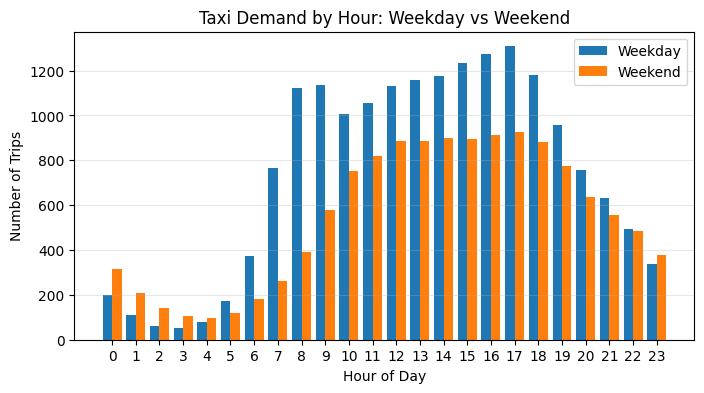

In [55]:
hours = hourly_weekend_avg.index

x = np.arange(len(hours))
width = 0.4

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    hourly_weekend_avg[False],
    width,
    label="Weekday"
)

plt.bar(
    x + width/2,
    hourly_weekend_avg[True],
    width,
    label="Weekend"
)

plt.xticks(x, hours)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Hour: Weekday vs Weekend")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

Weekdays exhibit pronounced morning and evening peaks, indicating commuting behaviour during regular working hours. In contrast, weekends show substantially higher demand during the night and early morning, suggesting increased leisure and nightlife-related travel. The absence of a strong morning peak further reflects the reduced importance of work-related trips on weekends.

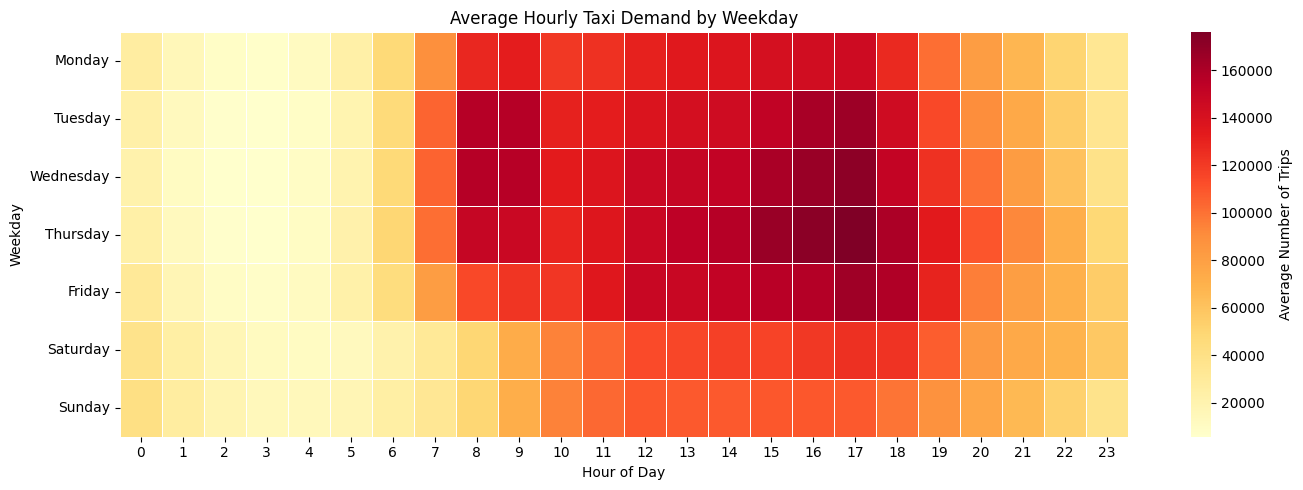

In [58]:
# Average hourly demand for each weekday
heatmap_data = (
    taxi_data
    .groupby(["weekday", "hour"])
    .size()
    .groupby(level=[0, 1])
    .mean()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Average Number of Trips"}
)

plt.title("Average Hourly Taxi Demand by Weekday")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")

plt.tight_layout()
plt.show()

The heatmap highlights highly regular intraday demand patterns across all weekdays. Demand is consistently lowest during the early morning hours and increases rapidly after approximately 6 a.m. From Tuesday to Thursday, demand remains at a particularly high level throughout the working day, reaching its maximum during the late afternoon. In contrast, Saturdays and Sundays exhibit a noticeably weaker morning peak and a flatter demand profile, reflecting reduced commuter traffic and increased leisure-oriented travel.

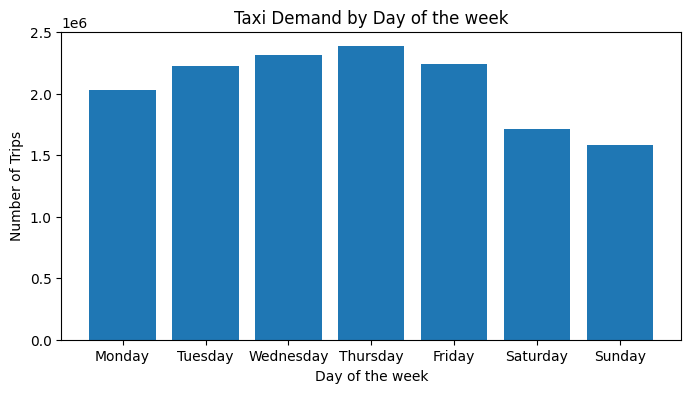

In [30]:
plt.figure(figsize=(8, 4))
plt.bar(weekly_demand.index, weekly_demand.values)

plt.title("Taxi Demand by Day of the week")
plt.xlabel("Day of the week")
plt.ylabel("Number of Trips")

plt.show()

trip length analysis

In [31]:
taxi_data["Trip Miles"].describe()

count    1.449480e+07
mean     5.973191e+00
std      6.550663e+00
min      0.000000e+00
25%      1.040000e+00
50%      2.600000e+00
75%      1.087000e+01
max      8.122800e+02
Name: Trip Miles, dtype: float64

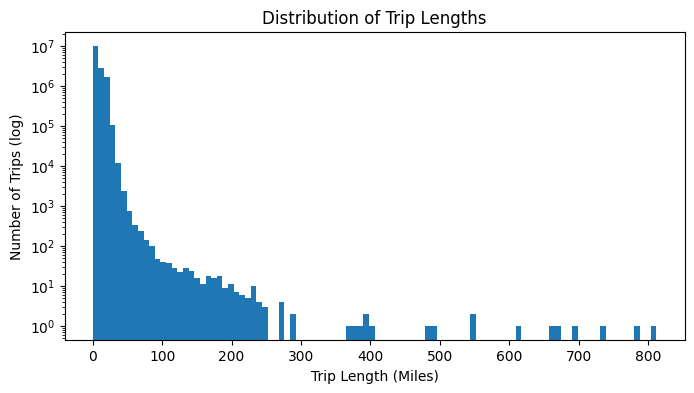

In [32]:
plt.figure(figsize=(8,4))
plt.hist(
    taxi_data["Trip Miles"],
    bins=100
)
plt.xlabel("Trip Length (Miles)")
plt.ylabel("Number of Trips (log)")
plt.title("Distribution of Trip Lengths")
plt.yscale("log")
plt.show()

In [33]:
hourly_trip_length = (
    taxi_data
    .groupby(
        taxi_data["hour"])["Trip Miles"]
    .mean()
)

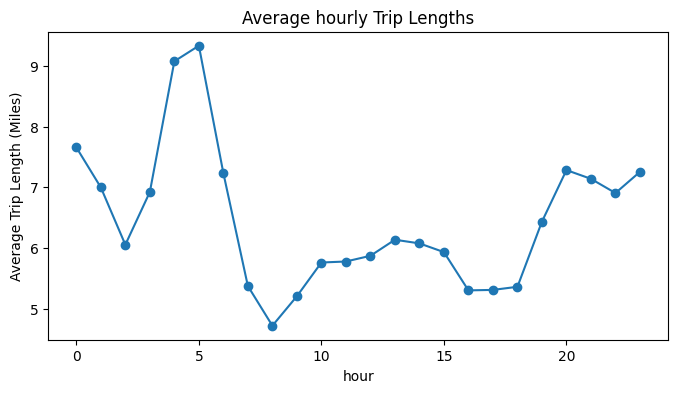

In [34]:
plt.figure(figsize=(8,4))
plt.plot(hourly_trip_length, marker = "o")
plt.xlabel("hour")
plt.ylabel("Average Trip Length (Miles)")
plt.title("Average hourly Trip Lengths")
plt.show()

price analysis

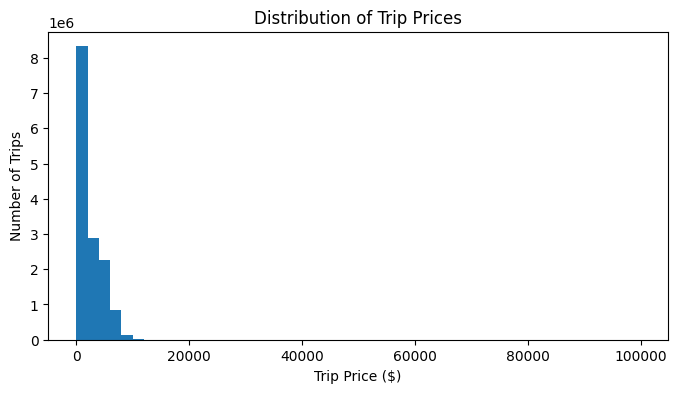

In [35]:
plt.figure(figsize=(8,4))

plt.hist(
    taxi_data["Trip Total"],
    bins=50
)

plt.title("Distribution of Trip Prices")
plt.xlabel("Trip Price ($)")
plt.ylabel("Number of Trips")

plt.show()

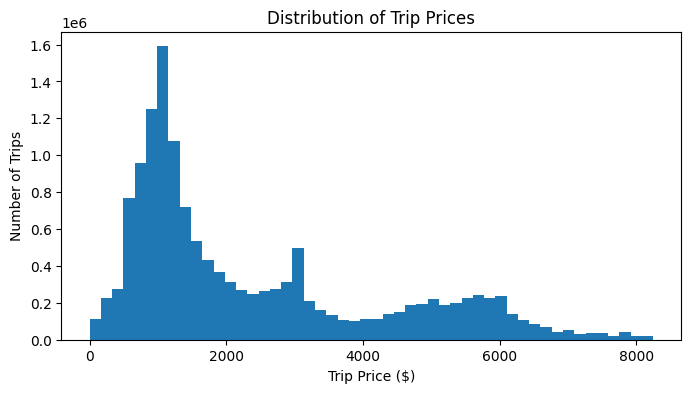

In [36]:
fare_99 = taxi_data["Trip Total"].quantile(0.99)

plt.figure(figsize=(8,4))

plt.hist(
    taxi_data.loc[
        taxi_data["Trip Total"] <= fare_99,
        "Trip Total"
    ],
    bins=50
)

plt.title("Distribution of Trip Prices")
plt.xlabel("Trip Price ($)")
plt.ylabel("Number of Trips")

plt.show()

In [37]:
taxi_data["Trip Total"].describe(
    percentiles=[0.5,0.9,0.95,0.99]
)

count    1.449480e+07
mean     2.475890e+03
std      2.125994e+03
min      0.000000e+00
50%      1.560000e+03
90%      5.680000e+03
95%      6.250000e+03
99%      8.250000e+03
max      9.990000e+04
Name: Trip Total, dtype: float64

In [38]:
hourly_avg_price = (
    taxi_data
    .groupby("hour")["Trip Total"]
    .mean()
)

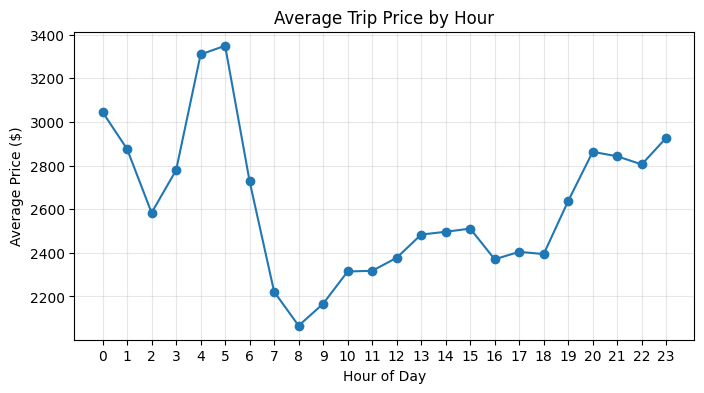

In [39]:
plt.figure(figsize=(8,4))

plt.plot(
    hourly_avg_price.index,
    hourly_avg_price.values,
    marker="o"
)

plt.title("Average Trip Price by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price ($)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()